Build a multiclass classifier for time_of_day classification, with three classes: day, dusk, night

In [1]:
#classes: day, dusk, night
#https://stackoverflow.com/questions/65154182/implement-separableconv2d-in-pytorch
#https://www.geeksforgeeks.org/machine-learning/depth-wise-separable-convolutional-neural-networks/
#https://arxiv.org/pdf/1801.04381 (MobileNetV2 paper - took depthwise separable convolution idea from here)
#https://arxiv.org/pdf/1512.03385 (Adaptive average pooling idea from here)

#Check multiclass classifier in Working Models for better notes etc especially on accuracy metrics etc

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import DataFrame
from torch import nn
import torchvision.transforms.v2 as transforms
from torch.utils.data import Dataset, DataLoader
import os
import torch

In [2]:
df = pd.read_csv('time-of-day-dataset_balanced.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,img_name,location,time_of_day,skyCondition,setting
0,0,0.0,a0001-jmac_DSC1459,outdoor,day,sun_sky,nature
1,1,1.0,a0002-dgw_005,indoor,day,mixed,people
2,2,2.0,a0003-NKIM_MG_8178,outdoor,day,sun_sky,man_made
3,3,3.0,a0004-jmac_MG_1384,outdoor,day,sun_sky,nature
4,4,4.0,a0005-jn_2007_05_10__564,outdoor,day,sun_sky,man_made


In [3]:
#Drop everything but img_name and time_of_day columns
df = df[['img_name', 'time_of_day']]
df.head()

,img_name,time_of_day
0,a0001-jmac_DSC1459,day
1,a0002-dgw_005,day
2,a0003-NKIM_MG_8178,day
3,a0004-jmac_MG_1384,day
4,a0005-jn_2007_05_10__564,day


In [4]:
df = pd.get_dummies(df, columns=['time_of_day'], dtype='long') # One-hot encode the time_of_day column
df.head()

,img_name,time_of_day_day,time_of_day_dusk,time_of_day_night
0,a0001-jmac_DSC1459,1,0,0
1,a0002-dgw_005,1,0,0
2,a0003-NKIM_MG_8178,1,0,0
3,a0004-jmac_MG_1384,1,0,0
4,a0005-jn_2007_05_10__564,1,0,0


In [5]:
#split into train, val, test dataframes
train_df = df.sample(frac=0.7, random_state=42) # 70% for training
temp_df = df.drop(train_df.index) # Drop training data from original dataframe
val_df = temp_df.sample(frac=0.5, random_state=42) # 15% for validation
test_df = temp_df.drop(val_df.index) # Remaining 15% for testing
print(f"Train entries: {train_df.shape[0]}, Val entries: {val_df.shape[0]}, Test entries: {test_df.shape[0]}")

Train entries: 5029, Val entries: 1078, Test entries: 1077


In [6]:
from torchvision.io import decode_image, ImageReadMode

class MainDataset(Dataset):
    def __init__(self, df:DataFrame, img_dir,transform=None):
        self.data: DataFrame = df
        self.transform = transform
        self.img_dir = img_dir

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx] #Get the row at the given index, iloc is [row, column] based indexing
        img_name = row['img_name']  # Assuming the first column is 'img_name'
        #Get the label tensor from the row, excluding the first column (img_name)
        label = torch.tensor(row[1:], dtype=torch.long)  # Convert the labels to tensor (excluding img_name, which is the input image name)

        img_path = os.path.join(self.img_dir, img_name)
        if not img_path.endswith('.jpg'):
            img_path += '.jpg'  # Ensure the image path ends with .jpg
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image file not found: {img_path}")
        image = decode_image(img_path, mode=ImageReadMode.RGB) #outputs tensor of shape (C, H, W) where C is the number of channels, H is the height and W is the width

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
standard_transforms = transforms.Compose([
    transforms.ToImage(), # Convert numpy array to PIL Image
    transforms.Resize((512, 512)), # Resize the image to 512x512 for consistency and to match the model input size
    transforms.ToDtype(torch.float32, scale=True), # Convert image to float32 tensor like .ToTensor(), scale means it will scale the pixel values to [0, 1] like .ToTensor()
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize the image with mean and std of ImageNet dataset
])

In [8]:
train_transforms = transforms.Compose([
    transforms.ToImage(), # Convert numpy array to PIL Image
    transforms.RandomApply([transforms.RandomRotation(degrees=180)], p=0.3), # Randomly rotate the image by a degree between -180 to 180 with a probability of 0.3
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.2), # Randomly adjust the sharpness of the image with a probability of 0.2
    transforms.RandomAdjustSharpness(sharpness_factor=0.5, p=0.2), # Randomly make the image blurry with a probability of 0.2
    transforms.RandomAutocontrast(p=0.2), # Randomly apply autocontrast to the image with a probability of 0.2

    transforms.Resize((512, 512)), # Resize the image to 512x512 for consistency and to match the model input size
    transforms.ToDtype(torch.float32, scale=True), # Convert image to float32 tensor like .ToTensor(), scale means it will scale the pixel values to [0, 1] like .ToTensor()
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize the image with mean and std of ImageNet dataset
])

In [10]:
train_dataset = MainDataset(train_df, 'raw_images_organised_time_of_day', transform=train_transforms)
val_dataset = MainDataset(val_df, 'raw_images_organised_time_of_day', transform=standard_transforms)
test_dataset = MainDataset(test_df, 'raw_images_organised_time_of_day', transform=standard_transforms)

In [11]:
print(train_dataset.transform)
print(test_dataset.transform)
print(val_dataset.transform)

Compose(
      ToImage()
      RandomApply(    RandomRotation(degrees=[-180.0, 180.0], interpolation=InterpolationMode.NEAREST, expand=False, fill=0))
      RandomAdjustSharpness(p=0.2, sharpness_factor=2)
      RandomAdjustSharpness(p=0.2, sharpness_factor=0.5)
      RandomAutocontrast(p=0.2)
      Resize(size=[512, 512], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)
Compose(
      ToImage()
      Resize(size=[512, 512], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)
Compose(
      ToImage()
      Resize(size=[512, 512], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)


In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [13]:
train_images, train_labels = next(iter(train_loader))
print(f"Train images shape: {train_images.shape}")  # Should be [batch_size, 3, 512, 512]
print(f"Train labels shape: {train_labels.shape}")  # Should be [batch_size, num_classes]

/var/folders/ch/bfx06mdj29ndjk1wx8vb4pz00000gn/T/ipykernel_45458/2406928921.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = torch.tensor(row[1:], dtype=torch.long)  # Convert the labels to tensor (excluding img_name, which is the input image name)


Train images shape: torch.Size([32, 3, 512, 512])
Train labels shape: torch.Size([32, 3])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


torch.float32
torch.int64


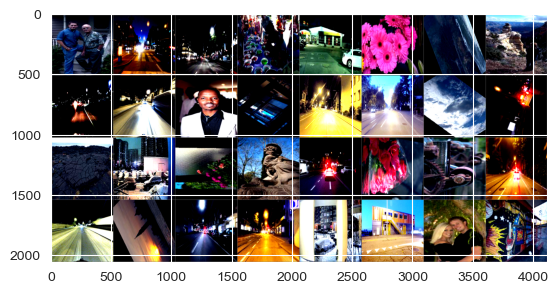

In [14]:
from torchvision.utils import make_grid

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

print(train_images.dtype)  # Check the shape of the images tensor
print(train_labels.dtype)  # Check the shape of the labels tensor

imshow(make_grid(train_images))

In [15]:
#device
device = torch.device("cuda" if torch.cuda.is_available() else "mps")

In [16]:
#class weights
#n_samples / (n_classes * np.bincount(y))

#Build my own class weight function

def class_weights(data: DataFrame):
    weights = []
    for col in data.columns[1:]:  # Skip the first column (img_name)
        classes = data[col].unique()
        total_samples = len(data[col])
        class_weight = total_samples / (len(classes) * data[col].value_counts())
        weights.append(class_weight[1]) # Assuming the positive class is the second one (1)
    class_weights = torch.tensor(weights, dtype=torch.float32)

    return class_weights

In [17]:
#cost function for multiclass classification with class weights
weights = class_weights(train_df) #Should help with class imbalance with dusk class
print(f"Class weights: {weights}")
criterion = nn.CrossEntropyLoss(weight=weights).to(device) # CrossEntropyLoss with weights and move to device

Class weights: tensor([1.1251, 4.5885, 1.1195])


This model using a combination of depthwise separable convolutions (from MobileNetV2 paper) and standard convolutional layers for , along with batch normalization, dropout, and adaptive average pooling. The model is designed for efficient image classification with a focus on reducing computational complexity while maintaining performance.

Adaptive average pooling idea: https://arxiv.org/pdf/1512.03385

Depthwise separable convolutions idea: https://arxiv.org/pdf/2109.00267

In [18]:
#model - look at discord for notes
#Model was underfitting so added more layers with more channels
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self, num_classes=3):
        super(Model, self).__init__()
        #Registering layers
        self.dropout = nn.Dropout(p=0.2) # Dropout layer with 20% dropout rate to prevent overfitting
        self.num_classes = num_classes
        self.input_conv = self.input_conv_block(3, 32)
        self.conv1 = self.depthwise_sep_conv(32, 32)
        self.conv2 = self.depthwise_sep_conv(32, 32)
        self.conv3 = self.depthwise_sep_conv(32, 64)
        self.conv4 = self.depthwise_sep_conv(64, 64)
        self.conv5 = self.depthwise_sep_conv(64, 64)
        self.adaptive_pooling_and_flatten_layer = self.adaptive_pooling_and_flatten(1)
        self.adaptive_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.classification_layer = nn.Linear(64, num_classes) # Final classification layer

    def depthwise_sep_conv(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):

            #Depthwise separable convolution block (channels not increased here, only spatial features learned in depthwise conv, channels combined in pointwise conv)
            depthwise_conv = nn.Conv2d(in_channels=in_channels, out_channels=in_channels, kernel_size=kernel_size, stride=stride, padding=padding, groups=in_channels) # Depthwise convolution, do all channels separately (groups=in_channels)

            #Above is from Mobilenetv2 paper, it reduces the matrix multiplication because the depthwise conv does not do cross channel learning, only spatial learning, meaning its only focus height and width, not depth (channels) - much less computation (check onenote notes for more details)

            #Channel count is upped to out channels at pointwise conv because pointwise is responsible for combining the channels together
            pointwise_conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=1) #Pointwise convolution, combine all channels together, allowing for cross channel learning, this is done using a 1x1 convolution (kernel_size=1 does this)

            #Applies a 1x1 convolution to combine the outputs of the depthwise convolution, allowing for cross-channel interaction.

            bn = nn.BatchNorm2d(out_channels) #out_channels is the expected feature map so it fits num_features in BatchNorm2d
            return nn.Sequential(
                depthwise_conv,
                pointwise_conv,
                bn
                # nn.ReLU() Use functional version of ReLU in forward method to save memory
            )

    def adaptive_pooling_and_flatten(self, output_size):
        return nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size), # Adaptive average pooling to get average per channel, making classification much easier
            nn.Flatten() # Flatten the output to feed into fully connected layer for classification
        )

    def input_conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1), # Initial conv layer to reduce the image size and increase the number of channels with some padding to retain image size initially

            nn.BatchNorm2d(out_channels),
            # nn.ReLU() Use functional version of ReLU in forward method to save memory
        )

    def forward(self, x):
        x = self.input_conv(x) # Initial conv layer
        x = F.relu(x) # Use functional version of ReLU to save memory
        #Ouput is: [batch_size, 32, 512, 512] because of padding in conv layer

        x = self.conv1(x)
        #Ouput is: [batch_size, 32, 512, 512] because of padding in conv layer
        x = F.relu(x) # Use functional version of ReLU to save memory

        x = self.conv2(x)
        #Ouput is: [batch_size, 32, 512, 512] because of padding in conv layer
        x = F.relu(x) # Use functional version of ReLU to save memory

        x = F.max_pool2d(x, 2) # Max pooling to reduce the image size and retain important features (2x2 pooling with stride 2) = half the size
        #Output is: [batch_size, 32, 256, 256]

        x = self.conv3(x)
        #Ouput is: [batch_size, 64, 256, 256] because of padding in conv layer and increased channels
        x = F.relu(x) # Use functional version of ReLU to save memory

        x = self.conv4(x)
        #Ouput is: [batch_size, 64, 256, 256] because of padding in conv layer
        x = F.relu(x) # Use functional version of ReLU to save memory

        x = self.dropout(x) # Dropout layer to prevent overfitting, later in model to prevent overfitting on complex features

        x = self.conv5(x)
        #Ouput is: [batch_size, 64, 256, 256] because of padding in conv layer
        x = F.relu(x) # Use functional version of ReLU to save memory

        x = self.adaptive_pooling_and_flatten_layer(x) # Adaptive average pooling to get average per channel and flatten for classification (check other model for details)
        #Output is: [batch_size, 64] because of adaptive average pooling to 1x1 and flattening (64 channels)
        #Much more efficient than using a fully connected layers after conv layers, which would require a lot more parameters and computation

        x = self.classification_layer(x) # Final classification layer
        #Output is: [batch_size, num_classes] because of final classification layer

        return x

    def train_epoch(self, train_loader, loss_values):
        running_loss = 0.0
        completed_epochs = len(loss_values) # Current epoch number based on the length of loss_values (because each epoch appends one loss value)
        for i, data in enumerate(train_loader):
            inputs, labels = data
            inputs, labels = inputs.to(device), torch.argmax(labels, dim=1).to(device) # Convert one-hot encoded labels to class indices
            optimizer.zero_grad() # Zero the gradients
            outputs = self(inputs) # Forward pass (forward propagation)
            loss = criterion(outputs, labels) # Compute the loss
            loss.backward() # Backward pass (backpropagation)
            optimizer.step() # Update the weights via optimizer using gradient descent
            if i % 10 == 0: # Print every 10 batches (mod division to check if i is multiple of 10)
                print(f"Epoch [{completed_epochs+1}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

            running_loss += loss.item() #add the loss for this batch to the running loss for the epoch

        epoch_loss = running_loss / len(train_loader) # Average loss for the epoch (completed epoch of batches)
        loss_values.append(epoch_loss) # Append the epoch loss to the list of loss values
        print(f"Epoch [{completed_epochs+1}] Loss: {epoch_loss:.4f}")

        return loss_values

In [19]:
model = Model(num_classes=3).to(device)
print(model)

Model(
  (dropout): Dropout(p=0.2, inplace=False)
  (input_conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv1): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
    (1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
    (1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
    (1): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-03, weight_decay=4e-5) #Possibly able to increase learning rate to 0.045 with Adam optimizer
#L2 regularization with weight decay of 4e-5 (0.00004) to prevent overfitting (from mobilenetv2 paper)

In [21]:
# Load existing model weights if available
# model.load_state_dict(torch.load("time-of-day-model-final.pth", map_location=device))

/var/folders/ch/bfx06mdj29ndjk1wx8vb4pz00000gn/T/ipykernel_45458/2848431218.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("time-of-day

<All keys matched successfully>

In [21]:
#Training loop
from datetime import datetime
initial_start_time = datetime.now()
average_epoch_completion_time = 0

def time_estimation(current_epoch, total_epochs, start_time):
    current_epoch = current_epoch + 1 # Convert from 0-indexed to 1-indexed for easier calculations
    if current_epoch == 0:
        return "Cannot estimate time remaining for the first epoch"
    elapsed_time = datetime.now() - start_time # Time elapsed since the start of training
    average_epoch_time = elapsed_time / current_epoch # Average time per epoch (current epoch is an integer of completed epochs)

    remaining_epochs = total_epochs - current_epoch  # Remaining epochs to complete
    estimated_remaining_time = average_epoch_time * remaining_epochs  # Estimated remaining time by multiplying average epoch time by remaining epochs
    return str(estimated_remaining_time).split('.')[0]  # Return as string, removing microseconds for cleaner output

def model_save(epoch, total_epochs):
    if (epoch + 1) % 5 == 0 or (epoch + 1) == total_epochs: # Save the model every 5 epochs and at the end of training
        clean_time = datetime.now().time().isoformat()
        model_path = f"time_of_day_model_epoch_{epoch+1}_iso{clean_time}.pth"
        torch.save(model.state_dict(), model_path)
        print(f"Model saved at epoch {epoch+1} to {model_path}")
        return f"model saved successfully @ {model_path}"
    epochs_until_next_save = (5 - (epoch % 5)) % 5 #mod division to get epochs until next save
    return f"model not saved this epoch, will next save in {epochs_until_next_save} epochs"


def training_loop(EPOCHS, train_loader, val_loader):
    loss_values = [] # List to store loss values for each epoch for plotting later
    vloss_values = [] # List to store validation loss values for each epoch for plotting later
    start_time = datetime.now()
    for epoch in range(EPOCHS):
        print(f"Epoch [{epoch+1}/{EPOCHS}]")
        model.train(mode=True) # Set the model to training mode

        loss_values = model.train_epoch(train_loader, loss_values) # Train the model for one epoch

        avg_loss = loss_values[-1] # Get the average loss for the epoch by getting the latest loss value in the list of loss values

        #validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad(): # No need to compute gradients during validation
            for i, vdata in enumerate(val_loader):
                vinputs, vlabels = vdata
                vinputs, vlabels = vinputs.to(device), torch.argmax(vlabels, dim=1).to(device) # Convert one-hot encoded labels to class indices
                voutputs = model(vinputs) # Forward pass (forward propagation)
                vloss = criterion(voutputs, vlabels) # Compute the loss
                val_loss += vloss.item() # Accumulate validation loss

        avg_vloss = val_loss / len(val_loader)
        vloss_values.append(avg_vloss) # Append the average validation loss to the list of validation loss values
        print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))
        time_remaining = time_estimation(epoch, EPOCHS, start_time) # Estimate the time remaining for training
        print(f"Estimated time remaining: {time_remaining}")
        print(f"Time elapsed since start of training: {datetime.now() - initial_start_time}")
        print('-'*50) # Print a separator line for better readability
        print(model_save(epoch, len(train_loader))) #call model save function

    return loss_values, vloss_values

In [22]:
loss_values, vloss_values = training_loop(15, train_loader, val_loader) # Train the model for 15 epochs

Epoch [1/15]


/var/folders/ch/bfx06mdj29ndjk1wx8vb4pz00000gn/T/ipykernel_7856/2406928921.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = torch.tensor(row[1:], dtype=torch.long)  # Convert the labels to tensor (excluding img_name, which is the input image name)


Epoch [1], Step [1/158], Loss: 1.1446
Epoch [1], Step [11/158], Loss: 0.9332
Epoch [1], Step [21/158], Loss: 0.8193
Epoch [1], Step [31/158], Loss: 0.6622
Epoch [1], Step [41/158], Loss: 0.5960
Epoch [1], Step [51/158], Loss: 0.6372
Epoch [1], Step [61/158], Loss: 0.7038
Epoch [1], Step [71/158], Loss: 0.4752
Epoch [1], Step [81/158], Loss: 0.7859
Epoch [1], Step [91/158], Loss: 0.4911
Epoch [1], Step [101/158], Loss: 0.4194
Epoch [1], Step [111/158], Loss: 0.4537
Epoch [1], Step [121/158], Loss: 0.5186
Epoch [1], Step [131/158], Loss: 0.4309
Epoch [1], Step [141/158], Loss: 0.4318
Epoch [1], Step [151/158], Loss: 0.4119
Epoch [1] Loss: 0.6171
LOSS train 0.6170765949955469 valid 0.47127026319503784
Estimated time remaining: 0:52:21
Time elapsed since start of training: 0:03:44.426998
--------------------------------------------------
model not saved this epoch, will next save in 0 epochs
Epoch [2/15]
Epoch [2], Step [1/158], Loss: 0.3506
Epoch [2], Step [11/158], Loss: 0.4249
Epoch [2]

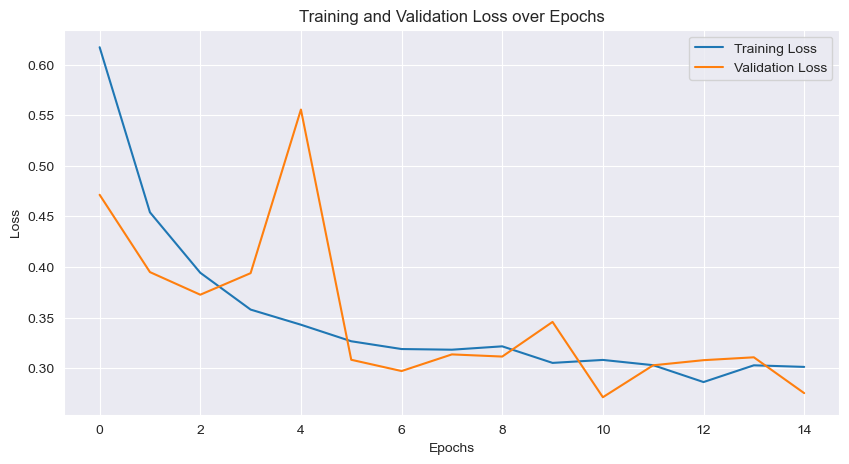

In [23]:
#Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(loss_values, label='Training Loss')
plt.plot(vloss_values, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

In [22]:
#Train set accuracy
model.eval()
from torcheval.metrics import MulticlassAccuracy
metric = MulticlassAccuracy()
with torch.no_grad(): # No need to compute gradients during evaluation because we are not training
    for data in train_loader: #get batches from train loader
        images, labels = data # Get a batch of data broken into images and labels
        images, labels = images.to(device), torch.argmax(labels, dim=1).to(device) # Convert one-hot encoded labels to class indices
        outputs = model(images) # Forward pass (forward propagation)
        prediction = torch.argmax(outputs, dim=1)
        metric.update(prediction, labels) #add batch predictions and labels to metric

accuracy = metric.compute()
print(f"train set accuracy: {accuracy:.4f}")


/var/folders/ch/bfx06mdj29ndjk1wx8vb4pz00000gn/T/ipykernel_45458/2406928921.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = torch.tensor(row[1:], dtype=torch.long)  # Convert the labels to tensor (excluding img_name, which is the input image name)


train set accuracy: 0.9366


In [23]:
#test set accuracy
model.eval()
metric = MulticlassAccuracy()
predictions = []
labels_list = []
with torch.no_grad(): # No need to compute gradients during evaluation because we are not training
    for data in test_loader: #get batches from test loader
        images, labels = data # Get a batch of data broken into images and labels
        images, labels = images.to(device), torch.argmax(labels, dim=1).to(device) # Convert one-hot encoded labels to class indices
        outputs = model(images) # Forward pass
        prediction = torch.argmax(outputs, dim=1)
        predictions.append(prediction)
        labels_list.append(labels)
        metric.update(prediction, labels) #add batch predictions and labels to metric

accuracy = metric.compute()
print(f"test set accuracy: {accuracy:.4f}")

/var/folders/ch/bfx06mdj29ndjk1wx8vb4pz00000gn/T/ipykernel_45458/2406928921.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = torch.tensor(row[1:], dtype=torch.long)  # Convert the labels to tensor (excluding img_name, which is the input image name)


test set accuracy: 0.9378


In [24]:
all_predictions = torch.cat(predictions, dim=0)
all_labels = torch.cat(labels_list, dim=0)
all_predictions_cpu_tensor = all_predictions.cpu().numpy()
all_labels_cpu_tensor = all_labels.cpu().numpy()

(3, 3)


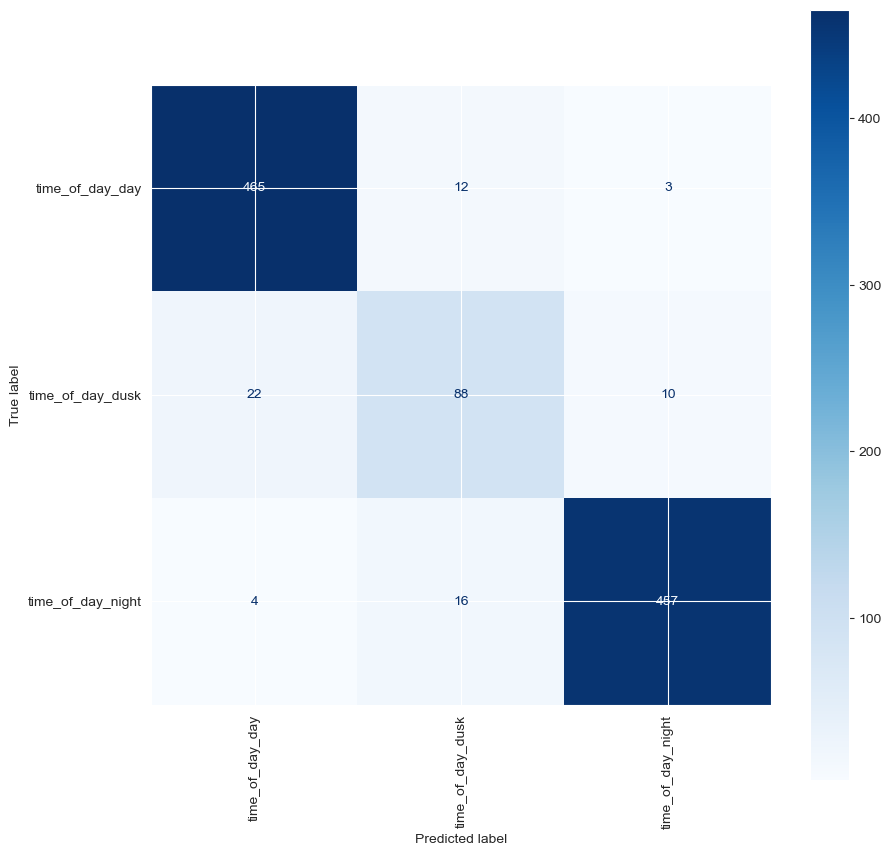

In [25]:
display_labels = df.columns[1:]
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(all_labels_cpu_tensor, all_predictions_cpu_tensor, labels=np.arange(len(display_labels)))

print(cm.shape)

matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

_, ax = plt.subplots(figsize=(10, 10))  # Create a figure and axis for the confusion matrix plot (much larger than default
matrix.plot(cmap='Blues', values_format='d', ax=ax, xticks_rotation=90)  # Plot the confusion matrix with blue color map and integer format